# 09 — Model Explainability Lab
## bd_replica_crm · por qué predice, dónde funciona y cómo explicarlo

Objetivo:

```text
predicción → explicación global → explicación por segmento
→ explicación local → sensibilidad → insight accionable
```

Incluye coeficientes/odds ratios, permutation importance, partial dependence,
sensibilidad, explicación local por lead, error por proyecto/asesor/canal/medio,
estabilidad temporal y smart insights.

No demuestra causalidad; para eso están los notebooks causales/experimentales.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

cwd=Path.cwd().resolve()
PROJECT_ROOT=cwd if (cwd/"pyproject.toml").exists() else cwd.parent
if not (PROJECT_ROOT/"pyproject.toml").exists():
    raise RuntimeError("Ejecuta este notebook dentro de bd_replica_crm.")

SRC=PROJECT_ROOT/"src"
if str(SRC) not in sys.path:
    sys.path.insert(0,str(SRC))

from replica_cygnus.settings import load_settings
from replica_cygnus.connections import connect_postgres

settings=load_settings(PROJECT_ROOT)
conn=connect_postgres(settings)

pd.set_option("display.max_columns",180)
pd.set_option("display.max_rows",180)
pd.set_option("display.width",260)

def sql_df(sql,params=None):
    with conn.cursor() as cur:
        cur.execute(sql,params or ())
        cols=[d.name for d in cur.description]
        rows=cur.fetchall()
    return pd.DataFrame(rows,columns=cols)

print("DB:",settings.postgres.database)
print("Inicio:",datetime.now().astimezone().isoformat(timespec="seconds"))


DB: medallio_dw
Inicio: 2026-09-07T17:18:47-05:00


## 1. Configuración


In [2]:
TARGET="minuta_60d"
MODEL="LogisticRegression"
FEATURE_SET="commercial"
SEGMENT_FILTER=None
TEST_FRACTION=.20
RANDOM_STATE=42
TOP_N=20


## 2. Feature sets


In [3]:
FEATURE_SETS={
"compact":[
    "hour_of_day","day_of_week","is_weekend",
    "client_prior_assignments_90d","days_since_previous_assignment"
],
"historical_rates":[
    "project_sep_rate_90d","project_minuta_rate_180d",
    "advisor_sep_rate_90d","advisor_minuta_rate_180d",
    "global_sep_rate_90d","global_minuta_rate_180d"
],
"commercial":[
    "codigo_proyecto","asesor","canal","medio",
    "hour_of_day","day_of_week","is_weekend",
    "client_prior_assignments_90d","days_since_previous_assignment",
    "project_leads_90d","project_sep_rate_90d","project_minuta_rate_180d",
    "advisor_leads_90d","advisor_sep_rate_90d","advisor_minuta_rate_180d",
    "global_sep_rate_90d","global_minuta_rate_180d"
]
}
features=FEATURE_SETS[FEATURE_SET]
features


['codigo_proyecto',
 'asesor',
 'canal',
 'medio',
 'hour_of_day',
 'day_of_week',
 'is_weekend',
 'client_prior_assignments_90d',
 'days_since_previous_assignment',
 'project_leads_90d',
 'project_sep_rate_90d',
 'project_minuta_rate_180d',
 'advisor_leads_90d',
 'advisor_sep_rate_90d',
 'advisor_minuta_rate_180d',
 'global_sep_rate_90d',
 'global_minuta_rate_180d']

## 3. Dataset


In [4]:
cols=[
"evidence_key","lead_id","decision_at",
"codigo_proyecto","asesor","canal","medio",
"hour_of_day","day_of_week","is_weekend",
"client_prior_assignments_90d","days_since_previous_assignment",
"project_leads_90d","project_sep_rate_90d","project_minuta_rate_180d",
"advisor_leads_90d","advisor_sep_rate_90d","advisor_minuta_rate_180d",
"global_sep_rate_90d","global_minuta_rate_180d",
"separacion_14d","minuta_60d"
]

data=sql_df("SELECT "+",".join(cols)+" FROM features.lead_evidence")
data["decision_at"]=pd.to_datetime(data["decision_at"],utc=True,errors="coerce")

if SEGMENT_FILTER:
    for c,v in SEGMENT_FILTER.items():
        data=data[data[c].eq(v)]

data=data[data[TARGET].notna()].copy()
data=data.sort_values(["decision_at","evidence_key"]).reset_index(drop=True)

print("rows:",len(data))
print("target rate:",data[TARGET].mean())


rows: 198809
target rate: 0.0017655136336886157


## 4. Split temporal


In [5]:
split_idx=int(len(data)*(1-TEST_FRACTION))
train=data.iloc[:split_idx].copy()
test=data.iloc[split_idx:].copy()

print("train:",len(train),"test:",len(test))
print("train max:",train["decision_at"].max())
print("test min:",test["decision_at"].min())


train: 159047 test: 39762
train max: 2025-10-31 22:59:00.467301+00:00
test min: 2025-10-31 23:25:04.953167+00:00


## 5. Pipeline y métricas


In [6]:
categorical=[
    c for c in features
    if data[c].dtype=="object" or str(data[c].dtype).startswith("string")
]
numeric=[c for c in features if c not in categorical]

num_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

cat_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("ohe",OneHotEncoder(handle_unknown="ignore"))
])

prep=ColumnTransformer([
    ("num",num_pipe,numeric),
    ("cat",cat_pipe,categorical)
])

if MODEL=="LogisticRegression":
    estimator=LogisticRegression(max_iter=1500,random_state=RANDOM_STATE)
elif MODEL=="RandomForest":
    estimator=RandomForestClassifier(
        n_estimators=300,min_samples_leaf=10,n_jobs=-1,random_state=RANDOM_STATE
    )
else:
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE)

model=Pipeline([("prep",prep),("model",estimator)])

X_train=train[features]
y_train=train[TARGET].astype(int)
X_test=test[features]
y_test=test[TARGET].astype(int)

model.fit(X_train,y_train)
prob=model.predict_proba(X_test)[:,1]

metrics=pd.DataFrame([{
    "model":MODEL,
    "n_train":len(train),
    "n_test":len(test),
    "base_rate":y_test.mean(),
    "roc_auc":roc_auc_score(y_test,prob) if y_test.nunique()>1 else np.nan,
    "average_precision":average_precision_score(y_test,prob),
    "brier":brier_score_loss(y_test,prob)
}])
metrics


,model,n_train,n_test,base_rate,roc_auc,average_precision,brier
0,LogisticRegression,159047,39762,0.005583,0.853858,0.025624,0.005508


## 6. Permutation importance global


,feature,importance_mean,importance_std
3,medio,0.018906,0.000491
0,codigo_proyecto,0.002340,0.001485
6,is_weekend,0.000126,0.000695
2,canal,0.000000,0.000000
1,asesor,0.000000,0.000000
8,days_since_previous_assignment,0.000000,0.000000
7,client_prior_assignments_90d,0.000000,0.000000
10,project_sep_rate_90d,0.000000,0.000000
9,project_leads_90d,0.000000,0.000000
13,advisor_sep_rate_90d,0.000000,0.000000


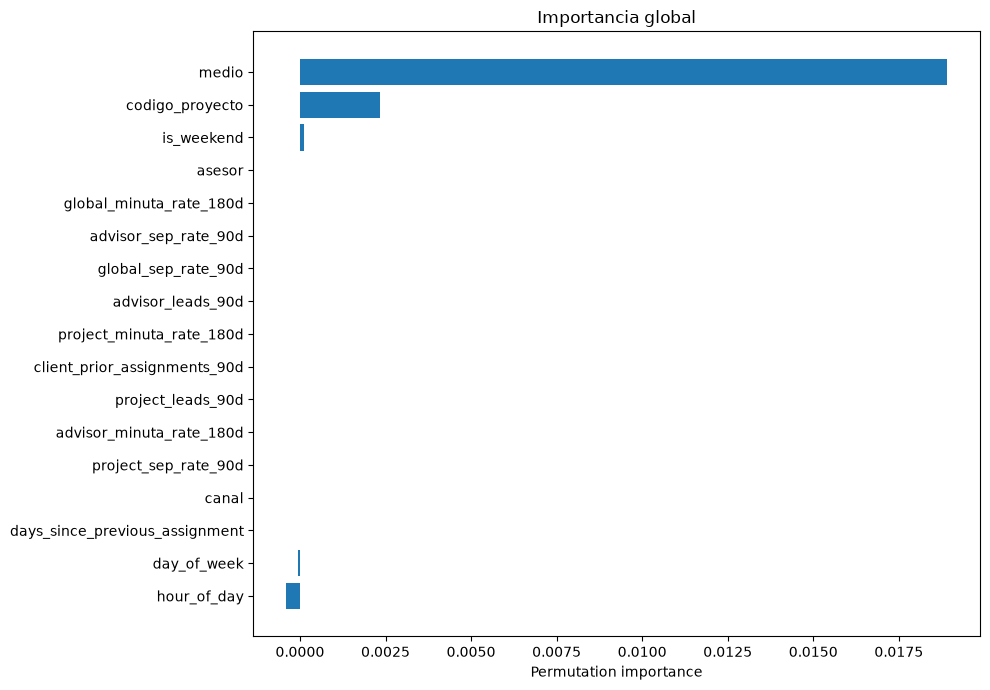

In [7]:
perm=permutation_importance(
    model,X_test,y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance=pd.DataFrame({
    "feature":features,
    "importance_mean":perm.importances_mean,
    "importance_std":perm.importances_std
}).sort_values("importance_mean",ascending=False)

display(importance.head(TOP_N))

p=importance.head(TOP_N).sort_values("importance_mean")
plt.figure(figsize=(10,7))
plt.barh(p["feature"],p["importance_mean"])
plt.xlabel("Permutation importance")
plt.title("Importancia global")
plt.tight_layout()
plt.show()


## 7. Coeficientes y odds ratios


In [8]:
coef_table=pd.DataFrame()

if MODEL=="LogisticRegression":
    names=model.named_steps["prep"].get_feature_names_out()
    coefs=model.named_steps["model"].coef_[0]

    coef_table=pd.DataFrame({
        "feature_encoded":names,
        "coef":coefs,
        "odds_ratio":np.exp(coefs)
    })
    coef_table["abs_coef"]=coef_table["coef"].abs()
    coef_table=coef_table.sort_values("abs_coef",ascending=False)

    display(coef_table.head(40))
else:
    print("Disponible cuando MODEL='LogisticRegression'.")


,feature_encoded,coef,odds_ratio,abs_coef
29,cat__medio_facebook,-4.192933,0.015102,4.192933
13,cat__codigo_proyecto_MT,1.612394,5.014800,1.612394
25,cat__medio_caseta de ventas,1.526793,4.603388,1.526793
14,cat__codigo_proyecto_NP,1.295220,3.651799,1.295220
30,cat__medio_feria inmobiliaria,1.188671,3.282715,1.188671
5,cat__codigo_proyecto_CRUZ,-0.954682,0.384935,0.954682
11,cat__codigo_proyecto_MA,-0.926263,0.396031,0.926263
6,cat__codigo_proyecto_CUBA,-0.911723,0.401831,0.911723
12,cat__codigo_proyecto_MD,0.703886,2.021594,0.703886
41,cat__medio_verdancy,-0.648909,0.522615,0.648909


## 8. Partial dependence manual


In [9]:
PDP_FEATURE="project_sep_rate_90d"

if PDP_FEATURE in numeric and len(X_test):
    lo=X_test[PDP_FEATURE].quantile(.05)
    hi=X_test[PDP_FEATURE].quantile(.95)
    values=np.linspace(lo,hi,20)

    rows=[]
    for v in values:
        tmp=X_test.copy()
        tmp[PDP_FEATURE]=v
        rows.append({
            "value":v,
            "avg_prediction":model.predict_proba(tmp)[:,1].mean()
        })

    pdp=pd.DataFrame(rows)
    display(pdp)

    plt.figure(figsize=(8,5))
    plt.plot(pdp["value"],pdp["avg_prediction"],marker="o")
    plt.xlabel(PDP_FEATURE)
    plt.ylabel("Predicción promedio")
    plt.title("Partial dependence")
    plt.show()
else:
    print("Selecciona una feature numérica válida.")


Selecciona una feature numérica válida.


## 9. Sensibilidad de una predicción


In [10]:
SENSITIVITY_FEATURE="project_sep_rate_90d"

if SENSITIVITY_FEATURE in numeric and len(test):
    row=test.iloc[[0]][features].copy()
    original=float(row[SENSITIVITY_FEATURE].iloc[0])
    std=float(train[SENSITIVITY_FEATURE].std(skipna=True))

    scenarios=[("-1sd",original-std),("base",original),("+1sd",original+std)]
    sens=[]

    for label,v in scenarios:
        tmp=row.copy()
        tmp[SENSITIVITY_FEATURE]=v
        sens.append({
            "scenario":label,
            "feature_value":v,
            "prediction":model.predict_proba(tmp)[:,1][0]
        })

    sensitivity=pd.DataFrame(sens)
    display(sensitivity)


## 10. Explicación local por lead


In [11]:
LOCAL_INDEX=0

local_row=test.iloc[[LOCAL_INDEX]].copy()
local_X=local_row[features].copy()
base_prob=model.predict_proba(local_X)[:,1][0]

local_effects=[]

for c in numeric:
    if pd.isna(local_X[c].iloc[0]):
        continue

    replacement=train[c].median()
    tmp=local_X.copy()
    tmp[c]=replacement
    p=model.predict_proba(tmp)[:,1][0]

    local_effects.append({
        "feature":c,
        "actual":local_X[c].iloc[0],
        "reference":replacement,
        "prediction_actual":base_prob,
        "prediction_if_reference":p,
        "delta":base_prob-p
    })

local_explanation=pd.DataFrame(local_effects)
local_explanation["abs_delta"]=local_explanation["delta"].abs()
local_explanation=local_explanation.sort_values("abs_delta",ascending=False)

print("Lead:",local_row["lead_id"].iloc[0])
print("Prediction:",base_prob)
print("Observed:",local_row[TARGET].iloc[0])
display(local_explanation.head(TOP_N))


Lead: 177149
Prediction: 0.015524538852603425
Observed: 0.0


,feature,actual,reference,prediction_actual,prediction_if_reference,delta,abs_delta
0,hour_of_day,18,15.0,0.015525,0.012889,0.002636,0.002636
1,day_of_week,5,4.0,0.015525,0.015639,-0.000114,0.000114
2,is_weekend,0,0.0,0.015525,0.015525,0.000000,0.000000


## 11. Explicación por proyecto


In [12]:
pred=test[
    ["evidence_key","decision_at","codigo_proyecto","asesor","canal","medio",TARGET]
].copy()

pred["prob"]=prob
pred["error"]=pred["prob"]-pred[TARGET]

segment_project=(
    pred.groupby("codigo_proyecto",dropna=False,as_index=False)
    .agg(
        n=(TARGET,"size"),
        observed=(TARGET,"mean"),
        predicted=("prob","mean"),
        mae=("error",lambda s:np.mean(np.abs(s))),
        bias=("error","mean")
    )
)

segment_project["calibration_gap_pp"]=(
    segment_project["predicted"]-segment_project["observed"]
)*100

display(
    segment_project[segment_project["n"]>=20]
    .sort_values("mae",ascending=False)
    .head(TOP_N)
)


,codigo_proyecto,n,observed,predicted,mae,bias,calibration_gap_pp
11,MT,3080,0.008442,0.006917,0.014994,-0.001525,-0.152470
15,TZ,563,0.010657,0.003141,0.013720,-0.007517,-0.751651
12,NP,7607,0.008808,0.005125,0.013683,-0.003683,-0.368314
10,MD,3632,0.008535,0.001832,0.010238,-0.006704,-0.670362
13,SL,3756,0.007721,0.000909,0.008573,-0.006812,-0.681219
5,EEUU,2416,0.004139,0.000885,0.004994,-0.003254,-0.325384
7,FX,5250,0.003429,0.001116,0.004498,-0.002313,-0.231285
8,GY,6766,0.003399,0.000871,0.004249,-0.002529,-0.252879
2,CP,5712,0.002101,0.001004,0.003081,-0.001097,-0.109670
16,UN,38,0.000000,0.001310,0.001310,0.001310,0.130976


## 12. Explicación por asesor / canal / medio


In [13]:
segment_tables={}

for dim in ["asesor","canal","medio"]:
    t=(
        pred.groupby(dim,dropna=False,as_index=False)
        .agg(
            n=(TARGET,"size"),
            observed=(TARGET,"mean"),
            predicted=("prob","mean"),
            mae=("error",lambda s:np.mean(np.abs(s))),
            bias=("error","mean")
        )
    )
    t=t[t["n"]>=20].copy()
    segment_tables[dim]=t

    print("\\n",dim.upper())
    display(t.sort_values("mae",ascending=False).head(TOP_N))


\n ASESOR


,asesor,n,observed,predicted,mae,bias
0,NaN,39762,0.005583,0.002316,0.00779,-0.003267


\n CANAL


,canal,n,observed,predicted,mae,bias
0,NaN,39762,0.005583,0.002316,0.00779,-0.003267


\n MEDIO


,medio,n,observed,predicted,mae,bias
18,referido,321,0.068536,0.005179,0.072758,-0.063357
8,expourbania,36,0.055556,0.003890,0.058875,-0.051666
4,contacto web,137,0.051095,0.001784,0.052645,-0.049311
10,feria inmobiliaria,1041,0.040346,0.012944,0.052082,-0.027402
3,caseta de ventas,1740,0.029885,0.017052,0.045893,-0.012833
16,paso por la zona,2034,0.023107,0.005428,0.028252,-0.017679
15,nexo,1354,0.016987,0.004528,0.021393,-0.012458
20,urbania,559,0.012522,0.004612,0.017017,-0.007910
12,instagram,532,0.007519,0.004652,0.012087,-0.002867
17,página web,746,0.004021,0.004803,0.008788,0.000782


## 13. Errores extremos


In [14]:
false_positive=(
    pred[pred[TARGET].eq(0)]
    .sort_values("prob",ascending=False)
    .head(TOP_N)
)

false_negative=(
    pred[pred[TARGET].eq(1)]
    .sort_values("prob",ascending=True)
    .head(TOP_N)
)

print("Falsos positivos extremos")
display(false_positive)

print("Falsos negativos extremos")
display(false_negative)


Falsos positivos extremos


,evidence_key,decision_at,codigo_proyecto,asesor,canal,medio,minuta_60d,prob,error
191199,22870896e5be2ac09c96f0e4dacf7e0d,2026-05-17 01:56:35.475865+00:00,MT,None,None,caseta de ventas,0.0,0.053702,0.053702
187694,5b4b9ddd7c737564e5defcb29ca0a174,2026-04-26 00:06:38.355456+00:00,MT,None,None,caseta de ventas,0.0,0.050593,0.050593
177937,3c088f2ab32ee768ba9604b3293ea6f4,2026-03-01 00:10:51.377340+00:00,MT,None,None,caseta de ventas,0.0,0.050593,0.050593
187691,308e0c2abf9c1a4a8e62d7b0f0a88c63,2026-04-26 00:05:00.742371+00:00,MT,None,None,caseta de ventas,0.0,0.050593,0.050593
185368,ce0eef0b56f1dd7848ea9d95b7d58be5,2026-04-12 00:27:24.736027+00:00,MT,None,None,caseta de ventas,0.0,0.050593,0.050593
193745,1acf2ba680f6c453681b1c0c025700af,2026-05-31 00:38:00.278317+00:00,MT,None,None,caseta de ventas,0.0,0.050593,0.050593
162327,cb613bffc2f4e7e4221d1793da4bbaaa,2025-11-30 00:34:32.645218+00:00,MT,None,None,caseta de ventas,0.0,0.050593,0.050593
196168,8891f0fcc12400ded0ed435ad239430e,2026-06-15 00:24:55.263813+00:00,MT,None,None,caseta de ventas,0.0,0.050238,0.050238
177373,d4a5e0560be9f1da5ead5b4e49148193,2026-02-25 03:01:00.102985+00:00,MT,None,None,caseta de ventas,0.0,0.048927,0.048927
159966,1c565ecc1d9660a6216d320409ec61df,2025-11-13 03:31:44.033549+00:00,MT,None,None,caseta de ventas,0.0,0.048582,0.048582


Falsos negativos extremos


,evidence_key,decision_at,codigo_proyecto,asesor,canal,medio,minuta_60d,prob,error
196227,376e92942a8c70818b1c98af37281cc1,2026-06-15 13:40:48.394029+00:00,SL,None,None,facebook,1.0,0.000015,-0.999985
180901,820c068de77440cf9dd6862749e0ebd9,2026-03-20 15:34:09.707740+00:00,SL,None,None,facebook,1.0,0.000016,-0.999984
191272,eb9a68f0db2f94e819111ae510a6a3a5,2026-05-17 14:37:41.423880+00:00,SL,None,None,facebook,1.0,0.000020,-0.999980
170669,75ad04c33f9ea3d9213c9c54596fe73e,2026-01-25 17:09:32.451322+00:00,SL,None,None,facebook,1.0,0.000024,-0.999976
198396,bc4c8409ff2c35c313b2d789761a70ef,2026-07-06 01:47:06.291314+00:00,GY,None,None,facebook,1.0,0.000029,-0.999971
191028,1c5a7410cb3e34ee3224f322067e3c34,2026-05-16 14:08:29.103554+00:00,CP,None,None,facebook,1.0,0.000032,-0.999968
172008,97b34aa88f86dbec182e0f2c7195b217,2026-01-31 02:55:18.625210+00:00,SL,None,None,facebook,1.0,0.000033,-0.999967
178015,f26b8e18fdcdd798c6a5a34735d3f1c4,2026-03-02 16:17:05.317659+00:00,NP,None,None,facebook,1.0,0.000062,-0.999938
190015,0b6b92f822e2fb8829fe2f44b9bee4ce,2026-05-10 04:58:55.505023+00:00,FX,None,None,facebook,1.0,0.000080,-0.999920
186471,373d2bbd399640e65de22f85301a0c75,2026-04-18 20:01:53.051469+00:00,NP,None,None,facebook,1.0,0.000099,-0.999901


## 14. Estabilidad temporal


C:\Users\dinat\AppData\Local\Temp\ipykernel_16400\3337885805.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  temporal["month"]=temporal["decision_at"].dt.to_period("M").astype(str)


,month,n,observed,predicted,mae,bias
0,2025-10,1,0.000000,0.015525,0.015525,0.015525
1,2025-11,3319,0.007532,0.004027,0.011396,-0.003505
2,2025-12,3427,0.004377,0.001804,0.006112,-0.002573
3,2026-01,6437,0.005282,0.001880,0.007068,-0.003402
4,2026-02,5706,0.005433,0.002029,0.007350,-0.003404
5,2026-03,5402,0.007775,0.004089,0.011655,-0.003686
6,2026-04,5128,0.005460,0.001556,0.006936,-0.003905
7,2026-05,5445,0.005510,0.001632,0.007052,-0.003878
8,2026-06,3967,0.003781,0.001974,0.005690,-0.001808
9,2026-07,930,0.002151,0.002211,0.004322,0.000060


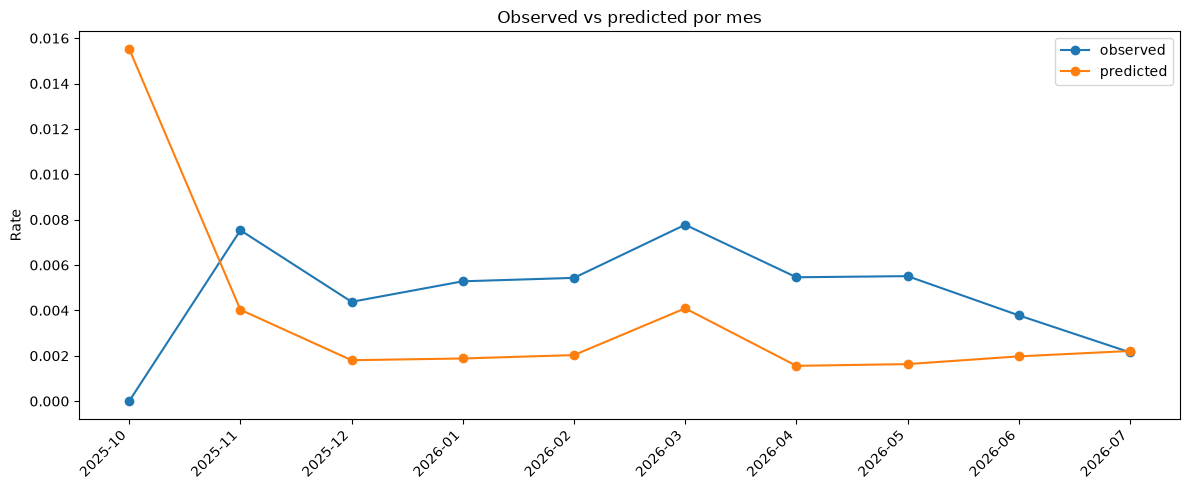

In [15]:
temporal=pred.copy()
temporal["month"]=temporal["decision_at"].dt.to_period("M").astype(str)

stability=(
    temporal.groupby("month",as_index=False)
    .agg(
        n=(TARGET,"size"),
        observed=(TARGET,"mean"),
        predicted=("prob","mean"),
        mae=("error",lambda s:np.mean(np.abs(s))),
        bias=("error","mean")
    )
)

display(stability.tail(24))

plt.figure(figsize=(12,5))
plt.plot(stability["month"],stability["observed"],marker="o",label="observed")
plt.plot(stability["month"],stability["predicted"],marker="o",label="predicted")
plt.xticks(rotation=45,ha="right")
plt.ylabel("Rate")
plt.title("Observed vs predicted por mes")
plt.legend()
plt.tight_layout()
plt.show()


## 15. Smart model insights


In [16]:
insights=[]

if len(importance):
    r=importance.iloc[0]
    insights.append(
        f"Mayor importancia por permutación: {r['feature']} ({r['importance_mean']:.4f})."
    )

valid=segment_project[segment_project["n"]>=20]

if len(valid):
    worst=valid.sort_values("mae",ascending=False).iloc[0]
    insights.append(
        f"Mayor error por proyecto: {worst['codigo_proyecto']} "
        f"(MAE={worst['mae']:.3f}, n={int(worst['n'])})."
    )

    biased=valid.assign(abs_bias=valid["bias"].abs()).sort_values(
        "abs_bias",ascending=False
    ).iloc[0]

    direction="sobrepredice" if biased["bias"]>0 else "subpredice"
    insights.append(
        f"Mayor sesgo: {biased['codigo_proyecto']}; el modelo {direction}."
    )

if len(stability):
    recent=stability.iloc[-1]
    insights.append(
        f"Último periodo: observado={recent['observed']:.1%}, "
        f"predicho={recent['predicted']:.1%}, MAE={recent['mae']:.3f}."
    )

print("=== MODEL INSIGHTS ===")
for i,x in enumerate(insights,1):
    print(f"{i}. {x}")


=== MODEL INSIGHTS ===
1. Mayor importancia por permutación: medio (0.0189).
2. Mayor error por proyecto: MT (MAE=0.015, n=3080).
3. Mayor sesgo: TZ; el modelo subpredice.
4. Último periodo: observado=0.2%, predicho=0.2%, MAE=0.004.


## 16. Gate de explicabilidad


In [17]:
gates=[]

def gate(name,passed,detail):
    gates.append({
        "gate":name,
        "status":"PASS" if passed else "FAIL",
        "detail":detail
    })

auc=float(metrics.iloc[0]["roc_auc"])

gate("Modelo discrimina",pd.notna(auc) and auc>.50,f"AUC={auc:.3f}")
gate("Permutation importance",len(importance)>0,f"features={len(importance)}")
gate(
    "Error segmentado evaluable",
    len(segment_project[segment_project["n"]>=20])>0,
    f"segments={len(segment_project[segment_project['n']>=20])}"
)
gate(
    "Split temporal",
    train["decision_at"].max()<test["decision_at"].min(),
    "train anterior a test"
)

gate_table=pd.DataFrame(gates)
gate_table


,gate,status,detail
0,Modelo discrimina,PASS,AUC=0.854
1,Permutation importance,PASS,features=17
2,Error segmentado evaluable,PASS,segments=16
3,Split temporal,PASS,train anterior a test


## 17. Tabla ejecutiva


In [18]:
executive_table=(
    segment_project[segment_project["n"]>=20][
        [
            "codigo_proyecto","n","observed","predicted",
            "calibration_gap_pp","mae","bias"
        ]
    ]
    .sort_values("mae",ascending=False)
)

executive_table.head(TOP_N)


,codigo_proyecto,n,observed,predicted,calibration_gap_pp,mae,bias
11,MT,3080,0.008442,0.006917,-0.152470,0.014994,-0.001525
15,TZ,563,0.010657,0.003141,-0.751651,0.013720,-0.007517
12,NP,7607,0.008808,0.005125,-0.368314,0.013683,-0.003683
10,MD,3632,0.008535,0.001832,-0.670362,0.010238,-0.006704
13,SL,3756,0.007721,0.000909,-0.681219,0.008573,-0.006812
5,EEUU,2416,0.004139,0.000885,-0.325384,0.004994,-0.003254
7,FX,5250,0.003429,0.001116,-0.231285,0.004498,-0.002313
8,GY,6766,0.003399,0.000871,-0.252879,0.004249,-0.002529
2,CP,5712,0.002101,0.001004,-0.109670,0.003081,-0.001097
16,UN,38,0.000000,0.001310,0.130976,0.001310,0.001310


## 18. Export opcional


In [19]:
EXPORT=False

if EXPORT:
    out=PROJECT_ROOT/"reports"/"model_explainability"
    out.mkdir(parents=True,exist_ok=True)

    metrics.to_csv(out/"metrics.csv",index=False)
    importance.to_csv(out/"permutation_importance.csv",index=False)
    segment_project.to_csv(out/"project_explainability.csv",index=False)
    stability.to_csv(out/"temporal_stability.csv",index=False)
    local_explanation.to_csv(out/"local_explanation.csv",index=False)
    gate_table.to_csv(out/"explainability_gates.csv",index=False)

    if len(coef_table):
        coef_table.to_csv(out/"coefficients_odds_ratios.csv",index=False)

    print("Export:",out)
else:
    print("EXPORT=False")


EXPORT=False


## 19. Qué sí y qué no afirma este notebook

Sí:
- qué variables pesan más;
- dónde el modelo se equivoca;
- dónde sobre/subpredice;
- cómo cambia una predicción ante perturbaciones;
- qué explica una predicción concreta.

No:
- que cambiar una variable cause un mejor resultado.

Para causalidad usa `03_causal_inference_lab.ipynb`,
`05_experiment_uplift_lab.ipynb` o el notebook del piloto.


In [20]:
conn.close(); print("Conexión cerrada.")


Conexión cerrada.
